# scratchkit — Supervised Learning, from scratch

This notebook walks through **every supervised-learning algorithm** in
[`scratchkit`](https://pypi.org/project/scratchkit/) (`import mlscratch`),
each one implemented from scratch in pure NumPy — no scikit-learn, no
PyTorch, anywhere in the library itself.

We *do* use `scikit-learn` in **this notebook**, but only for two things
that have nothing to do with the algorithms: loading real, classic
datasets, and (occasionally) a sanity-check comparison plot.

**Algorithms covered:** Linear / Ridge / Lasso / ElasticNet Regression,
Logistic Regression, KNN, Decision Trees, Random Forest, kernel SVM (SMO),
Gradient Boosting, AdaBoost.

Run this top to bottom — every cell is self-contained, in order.


In [ ]:
!pip install -q scratchkit

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_diabetes, make_moons, make_classification
from sklearn.datasets import load_wine

from mlscratch.supervised import (
    LinearRegression, RidgeRegression, LassoRegression, ElasticNet, LogisticRegression,
    KNeighborsClassifier, KNeighborsRegressor,
    DecisionTreeClassifier, DecisionTreeRegressor,
    RandomForestClassifier, RandomForestRegressor,
    SVC,
    GradientBoostingClassifier, GradientBoostingRegressor,
    AdaBoostClassifier,
)
from mlscratch.preprocessing import StandardScaler, train_test_split
from mlscratch.metrics import (
    accuracy_score, classification_report, r2_score, root_mean_squared_error,
)

np.random.seed(0)
plt.rcParams["figure.figsize"] = (6, 4)
print("scratchkit imports OK")


scratchkit imports OK


## 1. Regression dataset — Diabetes (real data)

442 patients, 10 baseline features (age, sex, BMI, blood pressure, six
serum measurements), target is a quantitative measure of disease
progression one year after baseline. This is a genuine, widely-used
benchmark (Efron et al., 2004), bundled with scikit-learn purely as a
*data source* — every model below is `scratchkit`'s own.

In [3]:
diabetes = load_diabetes()
Xd, yd = diabetes.data, diabetes.target
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.2, random_state=0)

scaler = StandardScaler().fit(Xd_train)
Xd_train_s, Xd_test_s = scaler.transform(Xd_train), scaler.transform(Xd_test)

print(f"{Xd.shape[0]} patients, {Xd.shape[1]} features")
print(f"train/test: {Xd_train.shape[0]}/{Xd_test.shape[0]}")


442 patients, 10 features
train/test: 353/89


## 2. Linear models: LinearRegression, Ridge, Lasso, ElasticNet

All four share the same closed-form / gradient-based linear-model
machinery; they differ only in the penalty added to the loss:

| Model | Penalty |
|---|---|
| `LinearRegression` | none (ordinary least squares) |
| `RidgeRegression` | $\alpha \lVert w \rVert_2^2$ |
| `LassoRegression` | $\alpha \lVert w \rVert_1$ (drives some coefficients to exactly 0) |
| `ElasticNet` | a weighted mix of both |


In [4]:
linear_models = {
    "LinearRegression": LinearRegression(),
    "RidgeRegression":  RidgeRegression(alpha=1.0),
    "LassoRegression":  LassoRegression(alpha=0.1),
    "ElasticNet":       ElasticNet(alpha=0.1, l1_ratio=0.5),
}

print(f"{'model':<18}{'test R^2':>10}{'test RMSE':>12}{'n_zero_coefs':>14}")
for name, model in linear_models.items():
    model.fit(Xd_train_s, yd_train)
    preds = model.predict(Xd_test_s)
    r2 = r2_score(yd_test, preds)
    rmse = root_mean_squared_error(yd_test, preds)
    n_zero = int(np.sum(np.abs(model.coef_) < 1e-8))
    print(f"{name:<18}{r2:>10.3f}{rmse:>12.2f}{n_zero:>14}")


model               test R^2   test RMSE  n_zero_coefs
LinearRegression       0.501       54.16             0
RidgeRegression        0.503       54.09             0
LassoRegression        0.501       54.16             0
ElasticNet             0.506       53.90             0


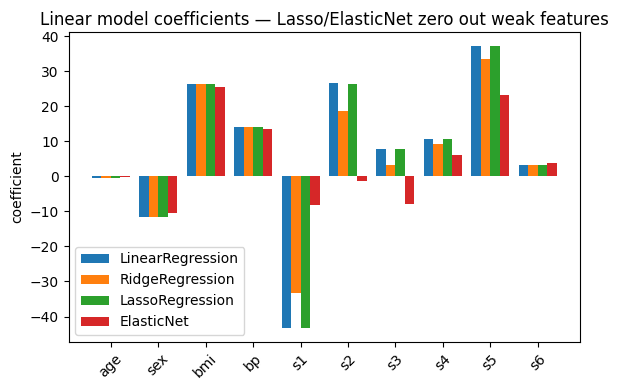

In [5]:
fig, ax = plt.subplots()
width = 0.2
feat_idx = np.arange(Xd.shape[1])
for i, (name, model) in enumerate(linear_models.items()):
    ax.bar(feat_idx + i * width, model.coef_, width, label=name)
ax.set_xticks(feat_idx + 1.5 * width)
ax.set_xticklabels(diabetes.feature_names, rotation=45)
ax.set_ylabel("coefficient")
ax.set_title("Linear model coefficients — Lasso/ElasticNet zero out weak features")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Classification dataset — Breast Cancer Wisconsin (real data)

569 tumor samples, 30 features computed from digitized images of a fine
needle aspirate, label is malignant vs. benign. A genuine diagnostic
benchmark.

In [6]:
bc = load_breast_cancer()
Xc, yc = bc.data, bc.target
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, stratify=yc, random_state=0)

c_scaler = StandardScaler().fit(Xc_train)
Xc_train_s, Xc_test_s = c_scaler.transform(Xc_train), c_scaler.transform(Xc_test)

print(f"{Xc.shape[0]} samples, {Xc.shape[1]} features, classes: {bc.target_names}")


569 samples, 30 features, classes: ['malignant' 'benign']


## 4. LogisticRegression

In [7]:
logreg = LogisticRegression(learning_rate=0.1, epochs=2000).fit(Xc_train_s, yc_train)
preds = logreg.predict(Xc_test_s)
print(f"accuracy: {accuracy_score(yc_test, preds):.3f}")
print(classification_report(yc_test, preds, target_names=list(bc.target_names)))


accuracy: 0.982
                precision     recall   f1-score    support

malignant            1.00       0.95       0.98         42
benign               0.97       1.00       0.99         72

accuracy                                   0.98        114
macro avg            0.99       0.98       0.98        114
weighted avg         0.98       0.98       0.98        114


## 5. K-Nearest Neighbours

Instance-based: predicts using the $k$ closest training points by
distance, no training phase beyond storing the data.

In [8]:
for k in (1, 3, 5, 11, 21):
    knn = KNeighborsClassifier(n_neighbors=k).fit(Xc_train_s, yc_train)
    print(f"k={k:<3} test accuracy: {knn.score(Xc_test_s, yc_test):.3f}")

knn_reg = KNeighborsRegressor(n_neighbors=7).fit(Xd_train_s, yd_train)
print(f"\nKNeighborsRegressor (diabetes) test R^2: {knn_reg.score(Xd_test_s, yd_test):.3f}")


k=1   test accuracy: 0.947
k=3   test accuracy: 0.974
k=5   test accuracy: 0.965
k=11  test accuracy: 0.974
k=21  test accuracy: 0.965

KNeighborsRegressor (diabetes) test R^2: 0.417


## 6. Decision Trees

A single CART tree, classification and regression. Shallow trees
under-fit; very deep ones over-fit the training data — the classic
bias/variance trade-off, visible directly in train vs. test accuracy.

In [9]:
print(f"{'max_depth':<12}{'train acc':>12}{'test acc':>12}")
for depth in (1, 2, 3, 5, 8, None):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(Xc_train_s, yc_train)
    label = "None" if depth is None else str(depth)
    print(f"{label:<12}{tree.score(Xc_train_s, yc_train):>12.3f}{tree.score(Xc_test_s, yc_test):>12.3f}")

tree_reg = DecisionTreeRegressor(max_depth=4).fit(Xd_train_s, yd_train)
print(f"\nDecisionTreeRegressor (diabetes) test R^2: {tree_reg.score(Xd_test_s, yd_test):.3f}")


max_depth      train acc    test acc
1                  0.916       0.912
2                  0.949       0.947
3                  0.969       0.956
5                  0.993       0.956


8                  1.000       0.974


None               1.000       0.974

DecisionTreeRegressor (diabetes) test R^2: 0.373


## 7. Random Forest

Bagging + random feature subsets over many trees. Out-of-bag (OOB)
scoring gives a free validation-style estimate with no held-out split.

In [10]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, oob_score=True, random_state=0)
rf.fit(Xc_train_s, yc_train)
print(f"OOB score:  {rf.oob_score_:.3f}")
print(f"test score: {rf.score(Xc_test_s, yc_test):.3f}")

top5 = np.argsort(rf.feature_importances_)[::-1][:5]
print("\nTop 5 most important features:")
for i in top5:
    print(f"  {bc.feature_names[i]:<25} {rf.feature_importances_[i]:.3f}")


OOB score:  0.949
test score: 0.965

Top 5 most important features:
  mean concave points       0.111
  worst perimeter           0.106
  worst area                0.098
  worst concave points      0.092
  worst radius              0.083


## 8. Kernel SVM (`SVC`) — trained via real Sequential Minimal Optimization

`scratchkit`'s `SVC` solves the dual SVM problem with Platt's SMO
algorithm, not a toy approximation. We show this on two interleaving
half-moons — a shape no *linear* boundary can separate, but an RBF
kernel handles easily.

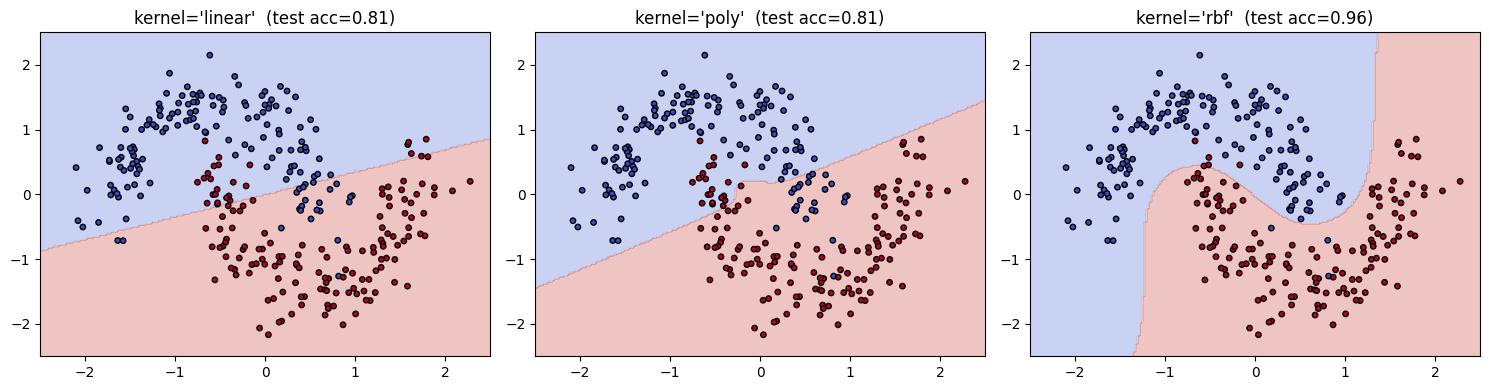

In [11]:
Xm, ym = make_moons(n_samples=300, noise=0.18, random_state=0)
Xm = StandardScaler().fit_transform(Xm)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, test_size=0.25, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, kernel in zip(axes, ("linear", "poly", "rbf")):
    model = SVC(C=1.0, kernel=kernel, gamma="scale", max_iter=30, random_state=0).fit(Xm_train, ym_train)
    acc = model.score(Xm_test, ym_test)

    xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 200), np.linspace(-2.5, 2.5, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="coolwarm", edgecolors="k", s=15)
    ax.set_title(f"kernel='{kernel}'  (test acc={acc:.2f})")
plt.tight_layout()
plt.show()


## 9. Gradient Boosting

Sequential ensemble: each tree corrects the previous ensemble's
residual errors, shrunk by a learning rate. We track the training loss
stage-by-stage via `staged_predict`.

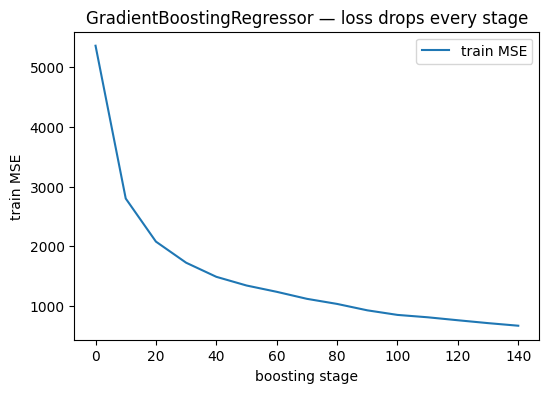

GradientBoostingClassifier test accuracy: 0.974


In [12]:
gbr = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=0)
gbr.fit(Xd_train_s, yd_train)

stages = list(range(0, 150, 10))
test_r2_by_stage = []
for n in stages:
    partial_pred = gbr.init_ + gbr.learning_rate * sum(t.predict(Xd_test_s) for t in gbr.estimators_[:n]) if n else np.full(len(yd_test), gbr.init_)
    test_r2_by_stage.append(r2_score(yd_test, partial_pred))

plt.plot(stages, gbr.train_score_[stages], label="train MSE")
plt.xlabel("boosting stage")
plt.ylabel("train MSE")
plt.title("GradientBoostingRegressor — loss drops every stage")
plt.legend()
plt.show()

gbc = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=0)
gbc.fit(Xc_train_s, yc_train)
print(f"GradientBoostingClassifier test accuracy: {gbc.score(Xc_test_s, yc_test):.3f}")


## 10. AdaBoost — SAMME vs SAMME.R

A weighted ensemble of decision stumps; SAMME.R uses each stump's full
probability estimate (not just its hard vote) and typically converges
in fewer rounds.

In [13]:
for algorithm in ("SAMME", "SAMME.R"):
    ada = AdaBoostClassifier(n_estimators=80, algorithm=algorithm, max_depth=1, random_state=0)
    ada.fit(Xc_train_s, yc_train)
    print(f"{algorithm:<8} test accuracy: {ada.score(Xc_test_s, yc_test):.3f}  (stumps used: {len(ada.estimators_)})")


SAMME    test accuracy: 0.982  (stumps used: 80)


SAMME.R  test accuracy: 0.965  (stumps used: 80)


## 11. Putting it all together — every classifier, one dataset

A final head-to-head on the same Breast Cancer train/test split.

model                 test accuracy
LogisticRegression            0.982
KNN (k=7)                     0.956
DecisionTree                  0.956


RandomForest                  0.974


SVC (rbf)                     0.965


GradientBoosting              0.974


AdaBoost                      0.965


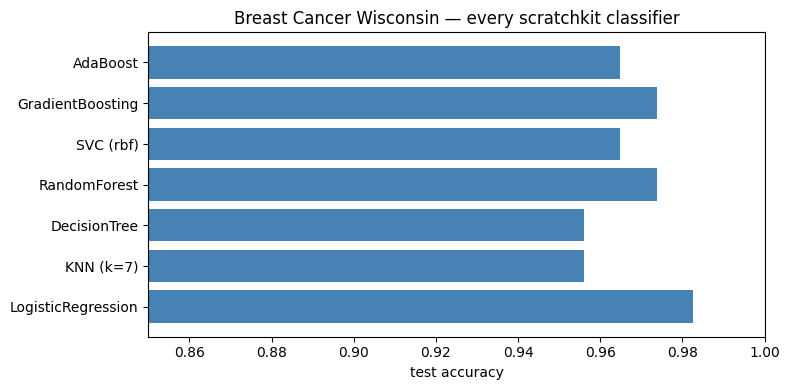

In [14]:
results = {
    "LogisticRegression":  LogisticRegression(learning_rate=0.1, epochs=2000),
    "KNN (k=7)":           KNeighborsClassifier(n_neighbors=7),
    "DecisionTree":        DecisionTreeClassifier(max_depth=5, random_state=0),
    "RandomForest":        RandomForestClassifier(n_estimators=150, max_depth=6, random_state=0),
    "SVC (rbf)":           SVC(kernel="rbf", gamma="scale", max_iter=20, random_state=0),
    "GradientBoosting":    GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=0),
    "AdaBoost":            AdaBoostClassifier(n_estimators=80, random_state=0),
}

print(f"{'model':<20}{'test accuracy':>15}")
scores = {}
for name, model in results.items():
    model.fit(Xc_train_s, yc_train)
    acc = accuracy_score(yc_test, model.predict(Xc_test_s))
    scores[name] = acc
    print(f"{name:<20}{acc:>15.3f}")

plt.figure(figsize=(8, 4))
plt.barh(list(scores.keys()), list(scores.values()), color="steelblue")
plt.xlabel("test accuracy")
plt.xlim(0.85, 1.0)
plt.title("Breast Cancer Wisconsin — every scratchkit classifier")
plt.tight_layout()
plt.show()


## Next steps

- See **`02_unsupervised_learning.ipynb`** for clustering, PCA, t-SNE, and association rules
- See **`03_bayesian_methods.ipynb`** for Naive Bayes, Gaussian Processes, HMMs, and more
- See **`04_reinforcement_learning.ipynb`** for Q-Learning through SAC
- See **`05_neural_networks.ipynb`** for MLPs, RNNs, CNNs, Transformers, and GANs — all from scratch

⭐ If this was useful, star the repo:
https://github.com/Mattral/ML-AI-Algorithms-from-scratch
